

<img src="images/office-and-workers-in-barcelona-spain.jpg" />

<br>

*In this notebook, we will walk through solving a classification problem using machine learning. To do so, we will introduce the Scikit-Learn machine learning library for Python.*

### Table of Contents

<a href="#sectioncase">Case Study: Employee Attrition at IBM</a>

<ol start="9">
    <li><a href="#section9">Machine Learning</a>
        <ol type=a>
            <br>
            <li><a href="#section9a">The K-Nearest Neighbors Algorithm</a></li>
            <br>
            <li><a href="#section9b">Using Scikit-Learn: An Example</a></li>
            <br>
            <li><a href="#section9c">Using Scikit-Learn: KNN</a></li>            
        </ol>
    </li>
    </ol>

In [41]:
# run this cell to import some necessary software
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D 

# set the random seed for reproducibility
np.random.seed(28)

## Case Study: Employee Attrition at IBM <a id= "sectioncase"></a>

*Employee attrition* refers to a decrease in employees at a company where the company does not intend to fill the vacancy afterward. Attrition, caused by resignations, retirements, or the elimination of job positions, is important for businesses to anticipate so they can keep costs low and properly distribute workloads.

Today, we'll try to predict whether or not an employee will leave their job using [a data set created by IBM](https://www.kaggle.com/pavansubhasht/ibm-hr-analytics-attrition-dataset/home). Because employee data is confidential, IBM's data set is fictional- it does not represent real employees. However, the data and the problem are structured very similarly to how actual companies such as IBM are approaching this very real problem.


Run the following cell to load the data.

In [42]:
# load the data
attrition = pd.read_csv("data/attrition-renamed.csv", index_col="EmployeeNumber")
# show the first 5 rows
attrition.head()


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,Gender,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
EmployeeNumber,,,,,,,,,,,,,,,,,
1,41,1,1,Sales,1,2,1,Sales Executive,4,Single,5993,8,1,11,1,6,4
2,49,0,2,Research & Development,8,1,0,Research Scientist,2,Married,5130,1,0,23,3,10,7
4,37,1,1,Research & Development,2,2,0,Laboratory Technician,3,Single,2090,6,1,15,3,0,0
5,33,0,2,Research & Development,3,4,1,Research Scientist,3,Married,2909,1,1,11,3,8,7
7,27,0,1,Research & Development,2,1,0,Laboratory Technician,2,Married,3468,9,0,12,3,2,2


This data set contains a wealth of information that could be used to predict attrition. Here's the **data dictionary**: the information about each feature (column) contained in the data set.


* `Age`: employee's age
* `Attrition`: the **response variable**. 1 if employee left IBM due to normal life circumstances, 0 if the employee stayed with IBM
* `BusinessTravel`: the amount of travel the employee does for business. 0 (no travel), 1 (rare travel), or 2 (frequent travel)
* `Department`: employee's home department. 'Sales', 'Research & Development', or 'Human Resources'
* `DistanceFromHome`: number of miles the employee has to travel to work
* `Education`: employee's highest level of education. 1 (below college), 2 (some college), 3 (bachelor's degree), 4 (master's degree), 5 (doctorate)
* `Gender`: 1 (female) or 0 (male)
* `JobRole`: 'Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', or 'Human Resources'
* `JobSatisfaction`: the employee's ranking of their satisfaction with their job. Minimum is 1, maximum is 4.
* `MaritalStatus`: 'Single', 'Married', or 'Divorced'
* `MonthlyIncome`: in dollars
* `NumCompaniesWorked`: the total number of companies the employee has worked at in their lifetime
* `OverTime`: whether or not the employee is eligible for overtime. 1 (yes) or 0 (no)
* `PercentSalaryHike`: for the employee's most recent salary increase, the percentage by which their salary increased
* `WorkLifeBalance`: employee's rating of their work-life balance. 1 (bad), 2 (good), 3 (better), 4 (best)
* `YearsAtCompany`: number of years employee has worked for IBM
* `YearsInCurrentRole`: number of years employee has worked for IBM in their current position

## 9. Machine Learning <a id= "section9"></a>

*Machine learning* is, essentially, pattern-matching. The process involves giving data to a computer, instructing it to find patterns within that data ("learn"), and then to perform a task based on what it has learned. We've already done machine learning in this course, when we trained a linear regression model in notebooks 07 and 08.

The bike-sharing problem from those notebooks and the attrition problem are both examples of **supervised learning**. In both cases, the data used to train the model have *labels*: each row in the data set includes the observed value of the response variable. For example, when we tried to predict bike ridership, we had the actual number of riders. Doing supervised learning is like studying with an answer key- you can use the key to check your answers, which can help you correct your mistakes and learn more quickly and accurately.

There are two main kinds of problems solved in supervised learning:
* **Regression problems** predict continuous amounts, as in the bike-sharing problem (predict number of riders based on features like temperature or day of the week). Another example would be predicting the optimal used car price based on its year, make, model, and mileage.
* **Classification problems** predict discrete categories or labels, as in our problem today (predicting whether or not an employee will leave a company). Another example would be labeling an image as "cat" or "dog" based on the image features.



### 9a. The K-Nearest Neighbors Algorithm <a id="section9a"></a>

Imagine you are given a simple classification problem. In this problem, there are two possible classes: red triangles and blue squares.

The next cell will create a plot of the data you're given to start out.

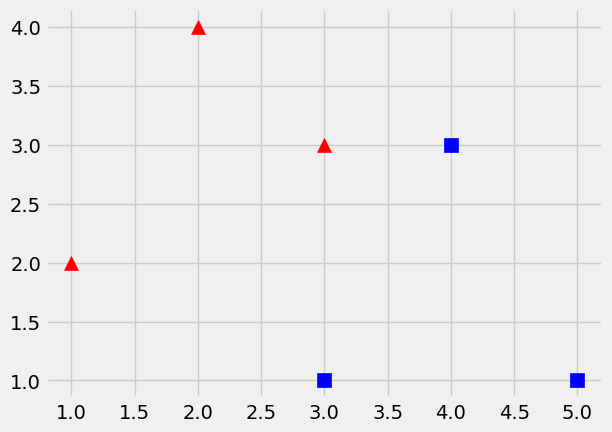

In [43]:
# run this cell to show the toy data
plt.scatter(x=[1, 2, 3], y=[2, 4, 3], c='r', marker='^', s=100)
plt.scatter(x=[4, 5, 3], y=[3, 1, 1], c='b', marker='s', s=100);

Now imagine you are given a new data point to classify. You don't know the correct category, but this new point must be either a red triangle or a blue square. We will represent this unknown new data point with a black circle.

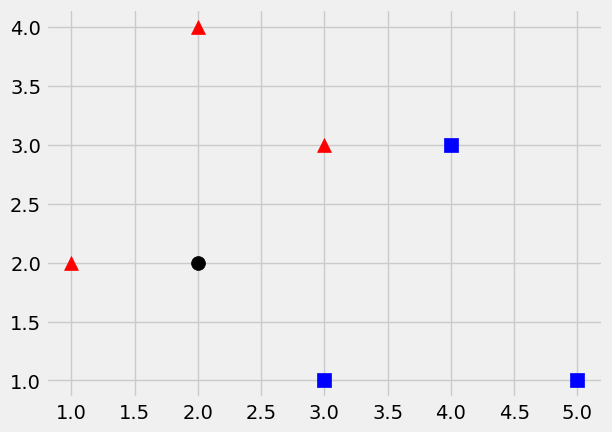

In [44]:
# add the new data point
plt.scatter(x=[1, 2, 3], y=[2, 4, 3], c='r', marker='^', s=100)
plt.scatter(x=[4, 5, 3], y=[3, 1, 1], c='b', marker='s', s=100)
plt.scatter(x=2, y=2, c='k', s=100);

Do you think it's more likely that the new black point is a red triangle or a blue square?

If you're like most people, in the absence of any other information you may have used the **K-Nearest Neighbors** algorithm.

K-Nearest Neighbors (or KNN) picks a class for the new point based on the classes of the closest points- its "neighbors". In this algorithm, "closest" is referring to *Euclidean distance*: the shortest straight-line distance between two points.

The "k" in KNN refers to the number of neighbors that "vote" on the new point's classification. For example, if k=1, the algorithm would find the point closest to the new point...

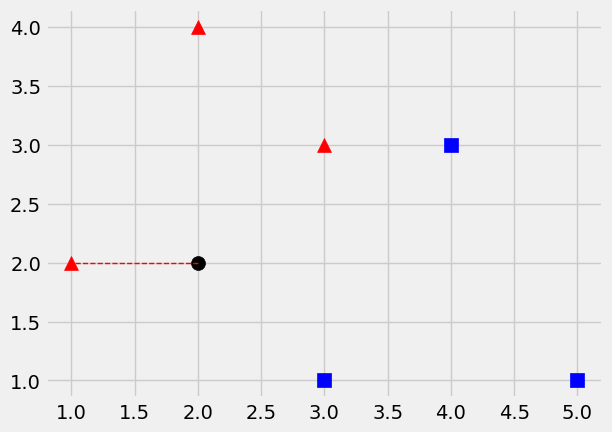

In [45]:
# show the 1 nearest neighbor
plt.scatter(x=[1, 2, 3], y=[2, 4, 3], c='r', marker='^', s=100)
plt.scatter(x=[4, 5, 3], y=[3, 1, 1], c='b', marker='s', s=100)
plt.plot([2, 1], [2, 2], 'r--', linewidth=1)
plt.scatter(x=2, y=2, c='k', s=100);

...and conclude that the new point should be a red triangle, because its neighbor is a red triangle.

If instead k=3, the algorithm would look for the three points closest to the new point...

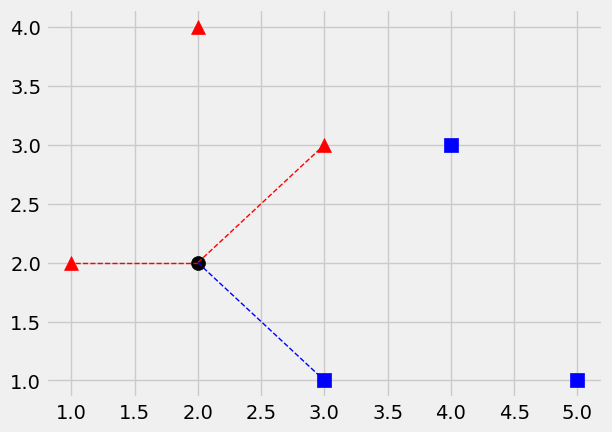

In [46]:
# show the 3 nearest neighbors
plt.scatter(x=[1, 2, 3], y=[2, 4, 3], c='r', marker='^', s=100)
plt.scatter(x=[4, 5, 3], y=[3, 1, 1], c='b', marker='s', s=100)
plt.plot([2, 3], [2, 3], 'r--', linewidth=1)
plt.plot([2, 1], [2, 2], 'r--', linewidth=1)
plt.plot([2, 3], [2, 1], 'b--', linewidth=1)
plt.scatter(x=2, y=2, c='k', s=100);

...and if all three points are weighted equally, it would decide the new point is a red triangle since the majority of the three neighbors are red.

The value of 'k' can make a big difference in the accuracy of the algorithm. Imagine you were asked to classify this new black point:

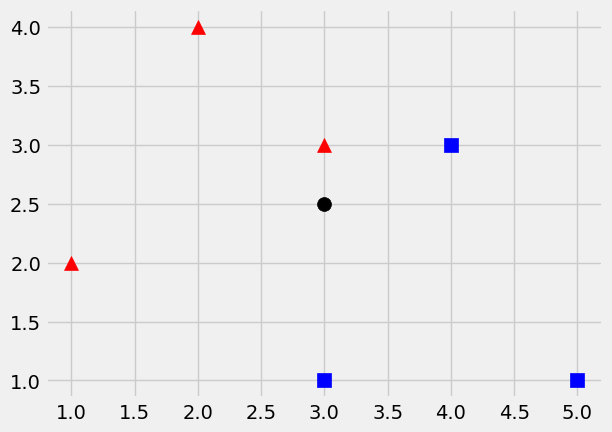

In [47]:
# add the new data point
plt.scatter(x=[1, 2, 3], y=[2, 4, 3], c='r', marker='^', s=100)
plt.scatter(x=[4, 5, 3], y=[3, 1, 1], c='b', marker='s', s=100)
plt.scatter(x=3, y=2.5, c='k', s=100);

<div class="alert alert-warning">
    <b>QUESTION:</b> Using the KNN algorithm, how would this point be classified for $k=1$, $k=2$, and $k=3$? Why could it be a problem to have $k$ be an even number in this case?
    </div>

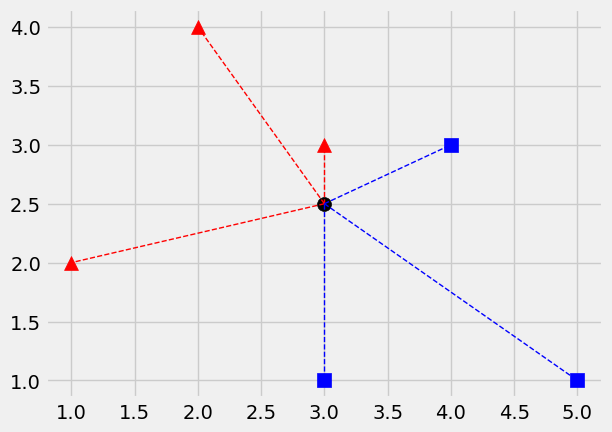

In [48]:
# Adding the line from all 6 points to the new point in question 
plt.scatter(x=[1, 2, 3], y=[2, 4, 3], c='r', marker='^', s=100)
plt.scatter(x=[4, 5, 3], y=[3, 1, 1], c='b', marker='s', s=100)

plt.plot([3, 3], [2.5, 3], 'r--', linewidth=1)
plt.plot([3, 1], [2.5, 2], 'r--', linewidth=1)
plt.plot([3, 2], [2.5, 4], 'r--', linewidth=1)
plt.plot([3, 3], [2.5, 1], 'b--', linewidth=1)
plt.plot([3, 4], [2.5, 3], 'b--', linewidth=1)
plt.plot([3, 5], [2.5, 1], 'b--', linewidth=1)

plt.scatter(x=3, y=2.5, c='k', s=100);

##### For k = 1, the new point is "red"
##### For k = 2, the new point is not classifiable its a tie, thats why for knn -> k is always set as odd
##### For k = 3, the closest points are 1 red and 2 blue and so it will be classified as a "blue"

### Using Scikit-Learn: KNN <a id="section9c"></a>

Now it's time to return to our IBM employee attrition data set, to see if we can use a k-nearest neighbors model to predict whether or not an employee will leave the company. This section will follow the steps in section 9b very closely- if you're stuck, check the LinearRegression code for some hints.

As a reminder, here's what our attrition data looks like:

In [49]:
# the first five rows of the attrition data
attrition.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,Gender,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
EmployeeNumber,,,,,,,,,,,,,,,,,
1,41,1,1,Sales,1,2,1,Sales Executive,4,Single,5993,8,1,11,1,6,4
2,49,0,2,Research & Development,8,1,0,Research Scientist,2,Married,5130,1,0,23,3,10,7
4,37,1,1,Research & Development,2,2,0,Laboratory Technician,3,Single,2090,6,1,15,3,0,0
5,33,0,2,Research & Development,3,4,1,Research Scientist,3,Married,2909,1,1,11,3,8,7
7,27,0,1,Research & Development,2,1,0,Laboratory Technician,2,Married,3468,9,0,12,3,2,2


Remember, our steps are:

1. Choose your explanatory variables (what you're going to use to make predictions) and response variable (what you want to predict) 
1. Split the data into training and testing sets 
2. Create a model in Python
3. Fit the data to the model
4. Make predictions using your fitted model
5. Score the accuracy of your model

Start by choosing explanatory and response variables. For this exercise, we'll try predicting attrition based on **monthly income**, **number of years in current role**, and **overtime eligibility**.



In [50]:
# choose explanatory and response variables

expl_vars_attrition = ["MonthlyIncome", "YearsInCurrentRole", "OverTime"]

resp_var_attrition = "Attrition"

Now, split the data into training and test sets. If you've chosen your variables correctly, you can just run the next few cells. The training data will be called `X_train_att` and `y_train_att`, while the test data will be called `X_test_att` and `y_test_att`.

In [51]:
# once you've chosen your variables, 
# create the X DataFrame
X_attrition = attrition.loc[:, expl_vars_attrition]

# show the first 5 rows
X_attrition.head()

,MonthlyIncome,YearsInCurrentRole,OverTime
EmployeeNumber,,,
1,5993,4,1
2,5130,7,0
4,2090,0,1
5,2909,7,1
7,3468,2,0


In [52]:
# once you've chosen your variables, 
# create the y array
y_attrition = attrition[resp_var_attrition]

# show the first 5 items
y_attrition.head()

EmployeeNumber
1    1
2    0
4    1
5    0
7    0
Name: Attrition, dtype: int64

In [53]:
# once you've chosen your variables, just run this cell
# split the data into training and test
X_train_att, X_test_att, y_train_att, y_test_att = train_test_split(X_attrition, y_attrition,
                                                                    train_size=0.8, test_size=0.2)

The next step is to create the KNN model. The first line of the next cell imports the code for the model, which is called `KNeighborsClassifier`. For now, we'll use the default number of neighbors, which is 5.



In [54]:
from sklearn.neighbors import KNeighborsClassifier

# create the KNeighborsClassifier

knn = KNeighborsClassifier()

In [55]:
# fit the knn model to the training data

knn.fit(X_train_att, y_train_att)

KNeighborsClassifier()

A fitted model can make predictions. Use the fitted model's `predict` to predict attrition for the test data. `predict` takes only one argument: an X matrix of feature data with the same features (columns) that it was trained on.


In [56]:
# use the fitted knn model to predict attrition for the test data


knn_predictions = knn.predict(X_test_att)

knn_predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

Finally, let's evaluate the model. 

For KNN, the `score` method [returns the mean accuracy on the data and labels](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.score). Put another way, the score for KNN is the proportion of employees correctly labeled by the model- the number of correctly labeled employees divided by the total number of employees. So, a score of 1.0 indicates a perfect model, and a score of 0.0 indicates a model that got all classifications wrong.


In [57]:
# use the fitted knn model to score predictions for the test data

knn_score = knn.score(X_test_att, y_test_att)

# show the score
knn_score

0.8061224489795918

#### Visualization
When evaluating the KNN model, it can also be helpful to visualize the data so we can see the scope of the problem we're trying to solve. 

The following scatter plots plot our explanatory variables against each other. Every point represents a single employee, and the color and shape of the point indicate whether or not they left IBM: an orange circle indicates attrition and a blue triangle indicates the employee remained at IBM.

Because KNN assumes that points of the same class are near to each other, the ideal KNN scatter plot would have all points of the same type located next to each other on the plot. 

This plot shows monthly income and years in current role:

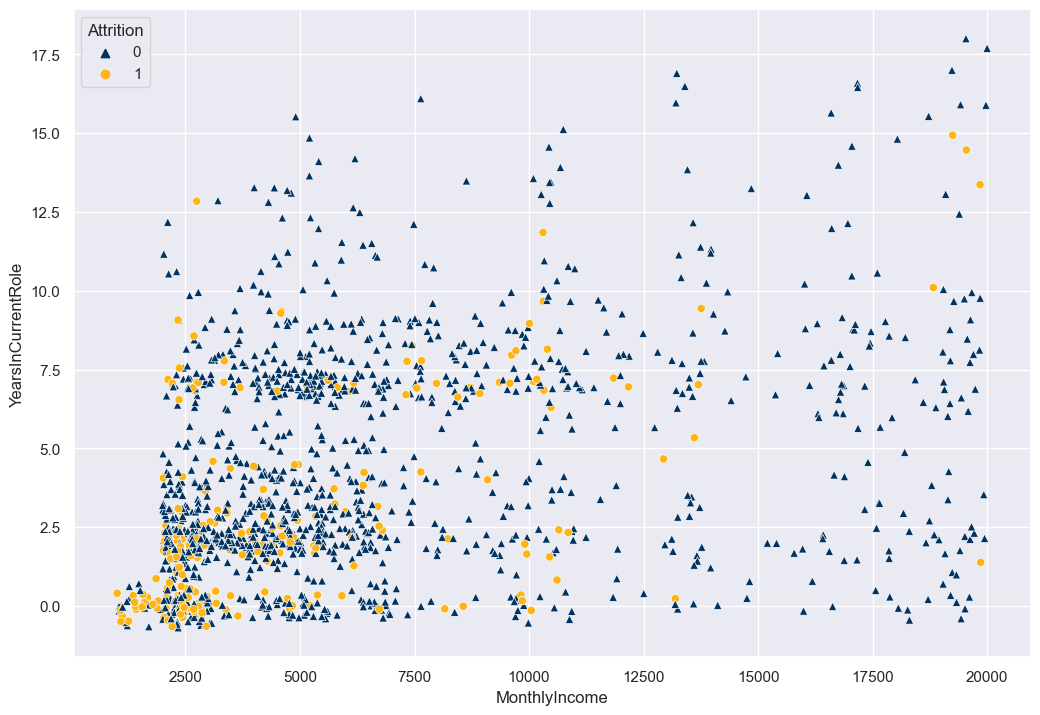

In [58]:
# make the plots bigger
sns.set(rc={'figure.figsize':(11,8)})

# create the scatter plot
sns.scatterplot(x=attrition["MonthlyIncome"], 
                # add a bit of jitter to YearsInCurrentRole so the points overlap less
                y=attrition["YearsInCurrentRole"] + np.random.normal(scale = 0.3, size=attrition.shape[0]), 
                data=attrition,
                hue="Attrition", style="Attrition", markers={0:"^", 1:"o"}, palette={0:"#003262", 1:"#FDB515"});

Sometimes, adding a third dimension can make a difference for the KNN algorithm. The next plot shows all three of our chosen explanatory variables: monthly income, years in current role, and overtime. Note that overtime is a binary value (employees are either eligible for overtime or not), so the overtime axis splits the points into two planes (one for each possible value of "OverTime").

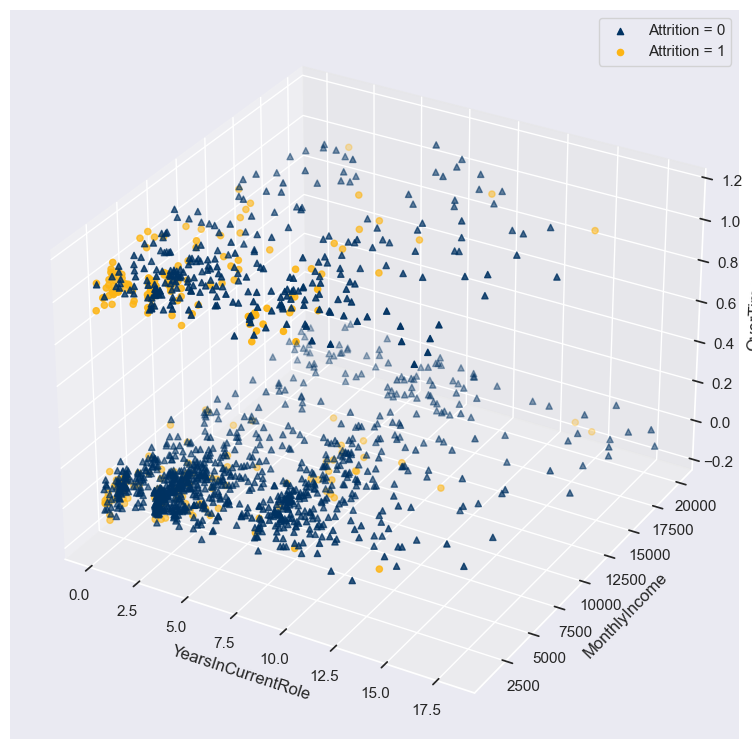

In [59]:
# make the 3D scatter plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

att_pos = attrition[attrition.Attrition == 1]
att_neg = attrition[attrition.Attrition == 0]

x_label = "YearsInCurrentRole"
y_label = "MonthlyIncome"
z_label = "OverTime"

for data, m , l, c in [(att_neg, "^", "Attrition = 0", "#003262"), (att_pos, "o", "Attrition = 1", "#FDB515")]:
    ax.scatter(data[x_label], data[y_label], (data[z_label] + np.random.normal(scale=0.05,size=data.shape[0])), 
               marker=m, label=l, color=c)

ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_zlabel(z_label)

plt.legend();

<div class="alert alert-warning">
    <b>QUESTION:</b> based on the model score, how well is our classifier working? Based on the scatter plot, who are the people most likely to be mis-classified, and how can you tell (hint: think about how KNN makes predictions)?
    </div>

Model will have a lesser probability in predicting attrition for employees with less experience & working over time. The better the demarcation of the different classifiers, the better the predicatability

## Classification using other algorithms

In [60]:
# Classifier using SVM - Support Vector Machine

from sklearn import svm

svm_model = svm.SVC()

In [61]:
# SVM fit and score
svm_model.fit(X_train_att, y_train_att)

svm_model_score = svm_model.score(X_test_att, y_test_att)

svm_model_score

0.8095238095238095

In [62]:
# Classifier using Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

In [63]:
# Random Forest fit and score
rf_model.fit(X_train_att, y_train_att)

rf_model_score = rf_model.score(X_test_att, y_test_att)

rf_model_score

0.7789115646258503

### Model Evaluation

##### Confusion matrix - takes the actual test Y and predicted test Y and shows the positives and negatives in 4 quadrants

In [64]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_test_att, knn_predictions)

print(confusion)

[[232   6]
 [ 51   5]]


## Way to interpret confusion matrix is

### In this case - I am considering "Attrition" to be the positive case. You can also redo the same thing with "No Attrition" to be be the positive case


###  There were a total of 246 ("no attrition => 0) cases in the y_test and the model predicted 240 correctly and 6 in- correctly - You can reference first row as True Negative and False Positive 

### There were a total of 48 ("attrition => 1) cases in the y_test and the model predicted only 3 correctly and 45 in correctly - You can reference second row as False Negative and True Positive 

### You can see that the model predicts "no attrition" better and fairs poorly in predicting "attrition"

### And this is because of we have an unbalanced data set .. techniques like oversampling or undersampling should be done 

### So do not go with just the accuracy score that model predicts, truly understand the false positives and false negatives and try to avoid one of the scenarios based on the risk profile tof the problem you are solving



In [65]:
# Define the different categories to calculate the score

# True Positives
TP = confusion[1, 1]
# True Negatives
TN = confusion[0, 0]
# False Positives
FP = confusion[0, 1]
# False Negatives
FN = confusion[1, 0]

In [66]:
# Classification accuracy 

accuracy = (TP + TN) / (TP+TN+FP+FN)

print (accuracy)

# this is the same knn_score

knn_score

0.8061224489795918


0.8061224489795918

In [67]:
# true positive rate or sensitivity/recall
# Sensitivity or recall is the ratio of correct positive predictions to the total no. of positive predictions. 


recall = TP / (TP+FN)

print (recall)

0.08928571428571429


In [68]:
# False Positive Rate

false_positive_rate = FP / (TN+FP)

print (false_positive_rate)

0.025210084033613446


In [69]:
# Precision 
# Ratio of correct predictions to the total no. of predicted correct predictions. 
# This measures how precise the classifier is when predicting positive instances.

precision = TP / (TP+FP)

print(precision)

0.45454545454545453


In [70]:
# F1-Score - an overall measure of a model’s accuracy that combines precision and recall
# Its between 0 & 1 with 1 being perfect and 0 means "bad"

f1_score = 2*precision*recall/(precision+recall)

print(f1_score)

0.1492537313432836


In [71]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

from sklearn.metrics import classification_report

class_names = ['no attrition', 'attrition']
print(classification_report(y_test_att, knn_predictions, target_names=class_names))

              precision    recall  f1-score   support

no attrition       0.82      0.97      0.89       238
   attrition       0.45      0.09      0.15        56

    accuracy                           0.81       294
   macro avg       0.64      0.53      0.52       294
weighted avg       0.75      0.81      0.75       294

